Generating transmitted intensity plots...

Plot 1: Main transmission curves with varying OD


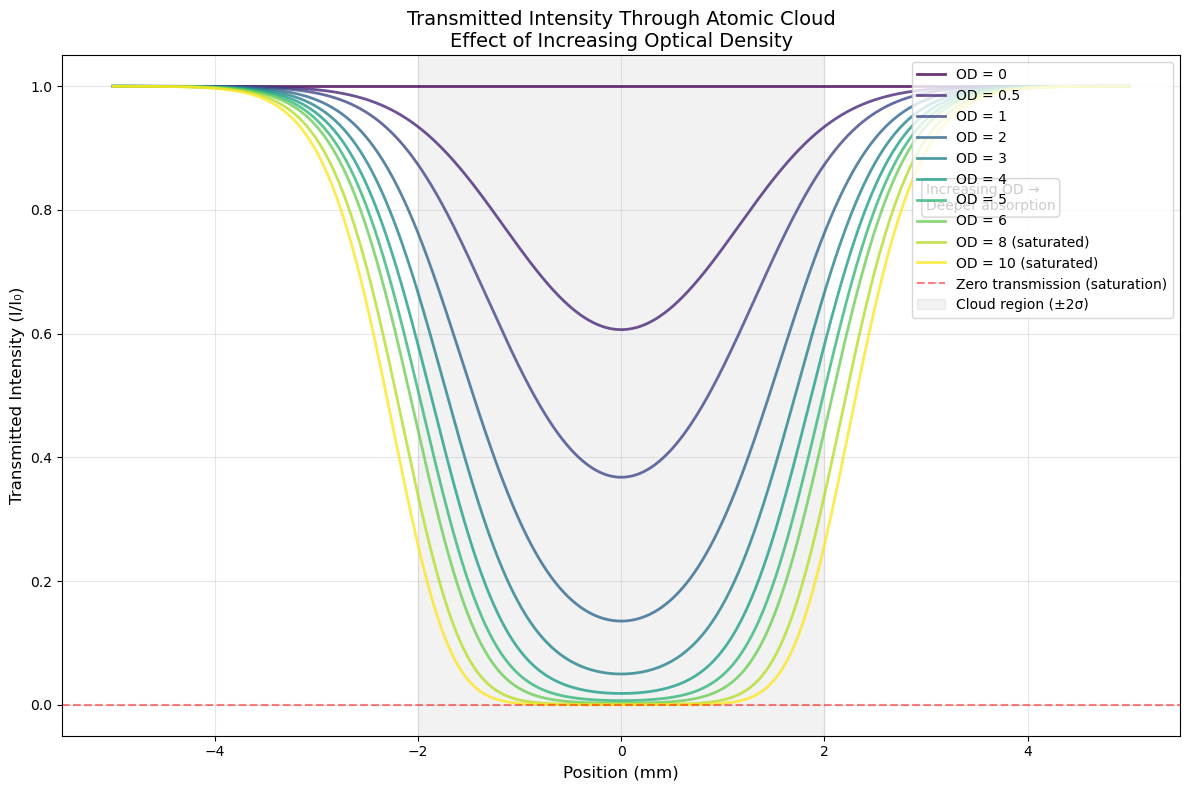


Plot 2: Detailed comparison (linear and log scales)


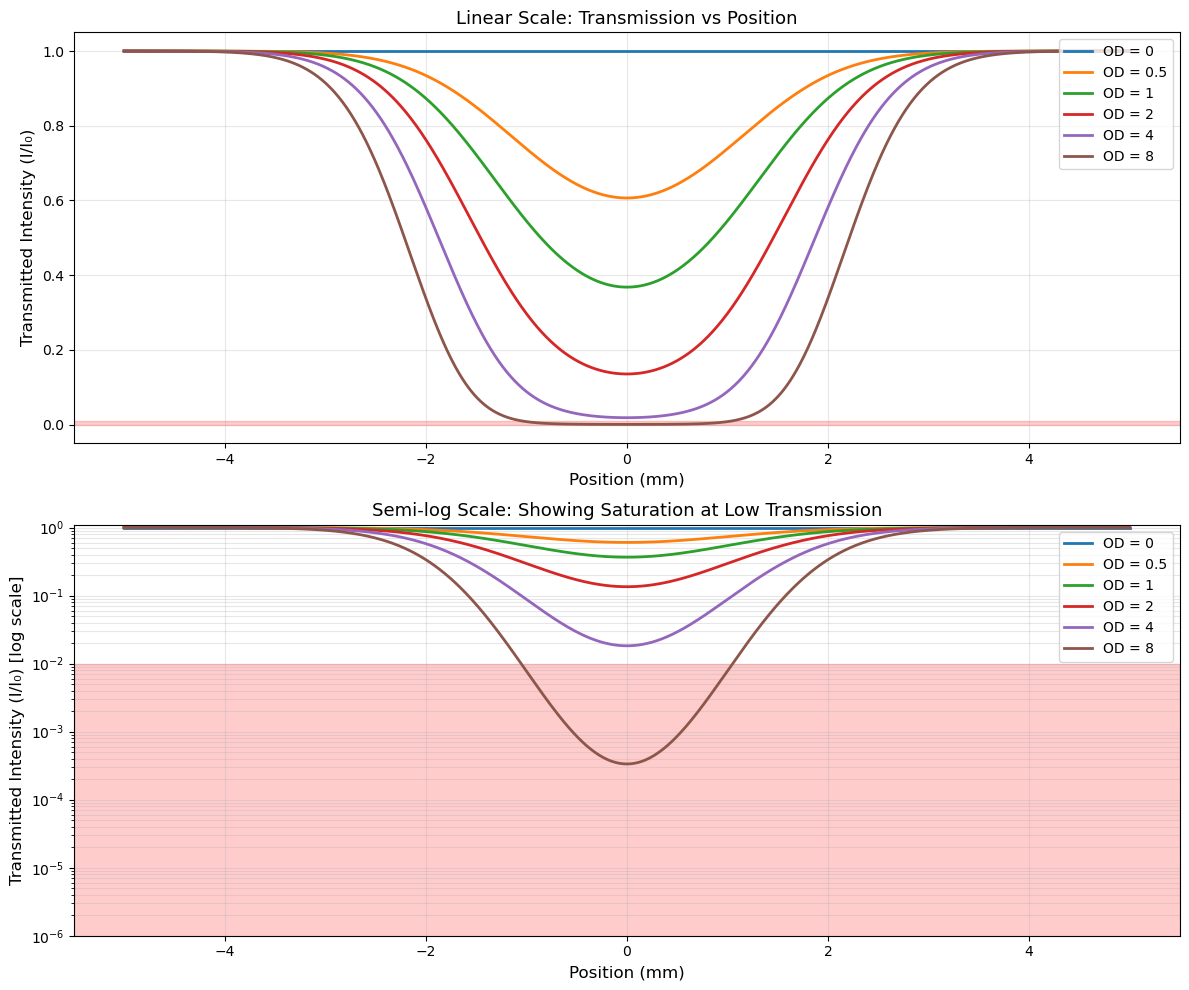


Plot 3: Saturation effect demonstration


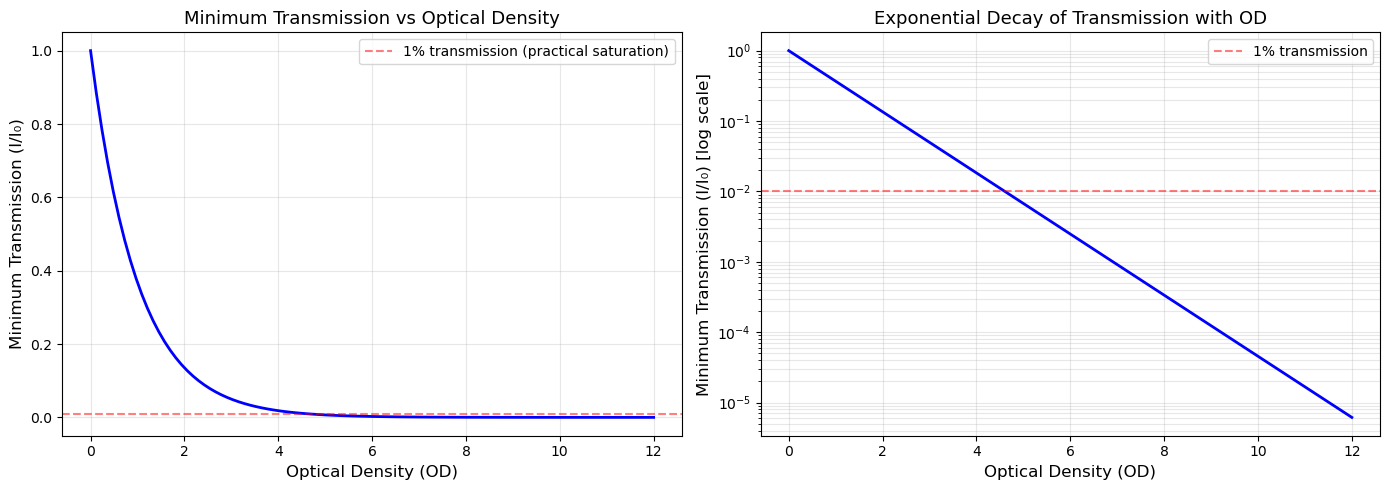

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

def gaussian_cloud(x, center, width, od):
    """
    Simulate an atomic cloud with Gaussian density distribution
    
    Parameters:
    x : position array
    center : center position of cloud
    width : width of cloud (sigma)
    od : optical density (peak absorption)
    """
    # Gaussian density profile
    density = np.exp(-(x - center)**2 / (2 * width**2))
    
    # Transmission using Beer-Lambert law: I = I0 * exp(-OD * density)
    transmission = np.exp(-od * density)
    
    return transmission

def create_transmission_plot():
    """
    Create a plot showing transmitted intensity vs position
    for different optical densities
    """
    # Create position array (mm)
    x = np.linspace(-5, 5, 1000)
    
    # Cloud parameters
    cloud_center = 0
    cloud_width = 1.0  # mm
    
    # Optical densities to plot (increasing values)
    od_values = [0, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]
    
    # Create colormap for different OD values
    colors = plt.cm.viridis(np.linspace(0, 1, len(od_values)))
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Plot transmission for each OD
    for i, od in enumerate(od_values):
        transmission = gaussian_cloud(x, cloud_center, cloud_width, od)
        
        # Label for legend
        label = f'OD = {od}' if od <= 6 else f'OD = {od} (saturated)'
        
        plt.plot(x, transmission, color=colors[i], 
                linewidth=2, label=label, alpha=0.8)
    
    # Add horizontal line at y=0 to show saturation
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, 
                label='Zero transmission (saturation)')
    
    # Add cloud region indicator
    plt.axvspan(cloud_center - 2*cloud_width, cloud_center + 2*cloud_width, 
                alpha=0.1, color='gray', label='Cloud region (±2σ)')
    
    # Customize the plot
    plt.xlabel('Position (mm)', fontsize=12)
    plt.ylabel('Transmitted Intensity (I/I₀)', fontsize=12)
    plt.title('Transmitted Intensity Through Atomic Cloud\n' + 
              'Effect of Increasing Optical Density', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', fontsize=10)
    
    # Set y-axis limits
    plt.ylim(-0.05, 1.05)
    
    # Add text explanation
    plt.text(3, 0.8, 'Increasing OD →\nDeeper absorption', 
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", 
                                  facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def create_detailed_comparison():
    """
    Create a more detailed plot showing the progression
    """
    x = np.linspace(-5, 5, 1000)
    cloud_center = 0
    cloud_width = 1.0
    
    # Select key OD values to highlight the progression
    od_highlight = [0, 0.5, 1, 2, 4, 8]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Standard linear plot
    ax1 = axes[0]
    for od in od_highlight:
        transmission = gaussian_cloud(x, cloud_center, cloud_width, od)
        ax1.plot(x, transmission, linewidth=2, label=f'OD = {od}')
    
    ax1.set_xlabel('Position (mm)', fontsize=12)
    ax1.set_ylabel('Transmitted Intensity (I/I₀)', fontsize=12)
    ax1.set_title('Linear Scale: Transmission vs Position', fontsize=13)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    ax1.set_ylim(-0.05, 1.05)
    
    # Plot 2: Semi-log plot to show details at low transmission
    ax2 = axes[1]
    for od in od_highlight:
        transmission = gaussian_cloud(x, cloud_center, cloud_width, od)
        # Avoid log(0) by setting very small values to a minimum
        transmission_plot = np.maximum(transmission, 1e-6)
        ax2.semilogy(x, transmission_plot, linewidth=2, label=f'OD = {od}')
    
    ax2.set_xlabel('Position (mm)', fontsize=12)
    ax2.set_ylabel('Transmitted Intensity (I/I₀) [log scale]', fontsize=12)
    ax2.set_title('Semi-log Scale: Showing Saturation at Low Transmission', fontsize=13)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.legend(loc='upper right')
    ax2.set_ylim(1e-6, 1.1)
    
    # Add saturation region indicator
    for ax in axes:
        ax.axhspan(0, 0.01, alpha=0.2, color='red', 
                  label='Saturation region (<1% transmission)')
    
    plt.tight_layout()
    plt.show()

def demonstrate_saturation_effect():
    """
    Show how the minimum transmission approaches zero as OD increases
    """
    # Calculate minimum transmission for a range of ODs
    od_range = np.linspace(0, 12, 100)
    min_transmission = np.exp(-od_range)  # At center of cloud
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Min transmission vs OD
    ax1.plot(od_range, min_transmission, 'b-', linewidth=2)
    ax1.set_xlabel('Optical Density (OD)', fontsize=12)
    ax1.set_ylabel('Minimum Transmission (I/I₀)', fontsize=12)
    ax1.set_title('Minimum Transmission vs Optical Density', fontsize=13)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0.01, color='r', linestyle='--', alpha=0.5, 
                label='1% transmission (practical saturation)')
    ax1.legend()
    
    # Plot 2: Same but semi-log to show exponential behavior
    ax2.semilogy(od_range, min_transmission, 'b-', linewidth=2)
    ax2.set_xlabel('Optical Density (OD)', fontsize=12)
    ax2.set_ylabel('Minimum Transmission (I/I₀) [log scale]', fontsize=12)
    ax2.set_title('Exponential Decay of Transmission with OD', fontsize=13)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.axhline(y=0.01, color='r', linestyle='--', alpha=0.5, 
                label='1% transmission')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Run all plots
if __name__ == "__main__":
    print("Generating transmitted intensity plots...")
    print("\nPlot 1: Main transmission curves with varying OD")
    create_transmission_plot()
    
    print("\nPlot 2: Detailed comparison (linear and log scales)")
    create_detailed_comparison()
    
    print("\nPlot 3: Saturation effect demonstration")
    demonstrate_saturation_effect()

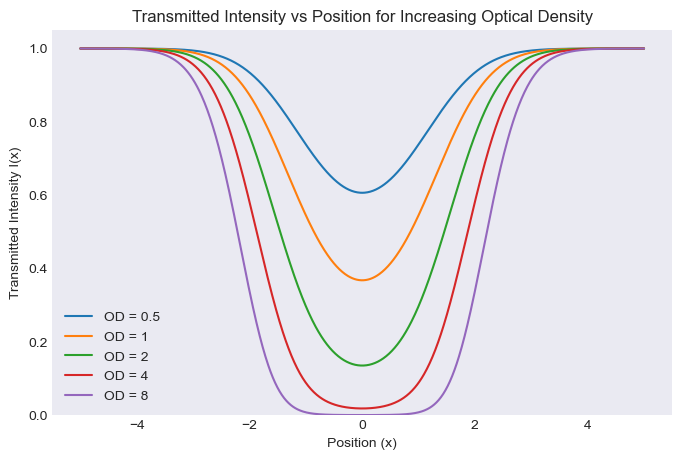

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Position axis
x = np.linspace(-5, 5, 1000)

# Beam intensity before cloud
I0 = 1.0

# Width of atom cloud
sigma = 1.0

# Different peak optical densities (increasing absorption)
OD0_values = [0.5, 1, 2, 4, 8]

plt.figure(figsize=(8, 5))

for OD0 in OD0_values:
    # Gaussian optical density profile
    OD = OD0 * np.exp(-x**2 / (2 * sigma**2))
    
    # Beer-Lambert transmission
    I = I0 * np.exp(-OD)
    
    plt.plot(x, I, label=f'OD = {OD0}')

# Formatting
plt.xlabel('Position (x)')
plt.ylabel('Transmitted Intensity I(x)')
plt.title('Transmitted Intensity vs Position for Increasing Optical Density')
plt.legend()
plt.grid()

plt.ylim(0, 1.05)
plt.show()

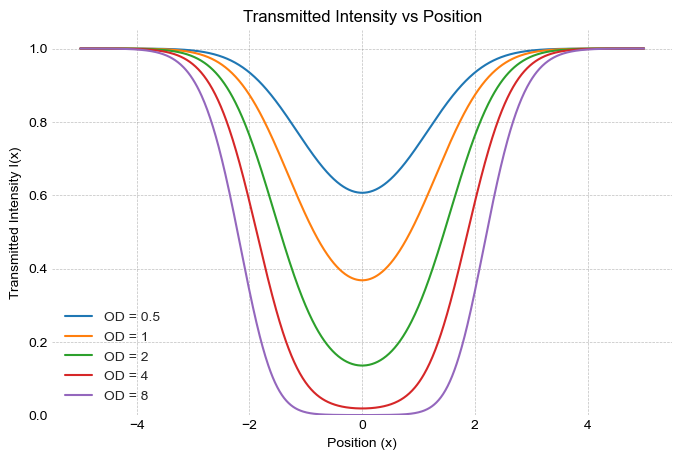

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Position axis
x = np.linspace(-5, 5, 1000)

# Beam intensity before cloud
I0 = 1.0

# Width of atom cloud
sigma = 1.0

# Different peak optical densities
OD0_values = [0.5, 1, 2, 4, 8]

# Create figure with white background
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

for OD0 in OD0_values:
    OD = OD0 * np.exp(-x**2 / (2 * sigma**2))
    I = I0 * np.exp(-OD)
    ax.plot(x, I, label=f'OD = {OD0}')

# Axis labels and title (black)
ax.set_xlabel('Position (x)', color='black')
ax.set_ylabel('Transmitted Intensity I(x)', color='black')
ax.set_title('Transmitted Intensity vs Position', color='black')

# Set axis/ticks to black
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')

# Grid (optional light gray so it's visible but subtle)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend()
ax.set_ylim(0, 1.05)

plt.show()